In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.feature_selection import SelectKBest, chi2

# 1. Create dummy data for Water Quality Classification

In [ ]:
# Potability: 0 (No), 1 (Yes)
data = {
    'ph': np.random.uniform(0, 14, 100),
    'Hardness': np.random.uniform(100, 300, 100),
    'Solids': np.random.uniform(5000, 50000, 100),
    'Chloramines': np.random.uniform(1, 10, 100),
    'Sulfate': np.random.uniform(100, 500, 100),
    'Conductivity': np.random.uniform(200, 800, 100),
    'Potability': np.random.choice([0, 1], 100)
}
df = pd.DataFrame(data)

# EDA
# Summary statistics
summary = df.describe()

# Plot 1: Target distribution


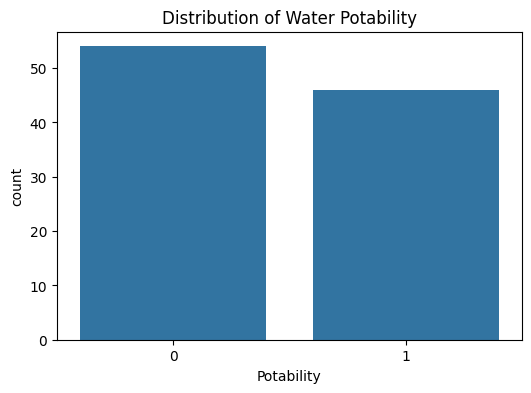

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Potability', data=df)
plt.title('Distribution of Water Potability')
plt.savefig('classification_target_dist.png')

# Plot 2: Correlation heatmap

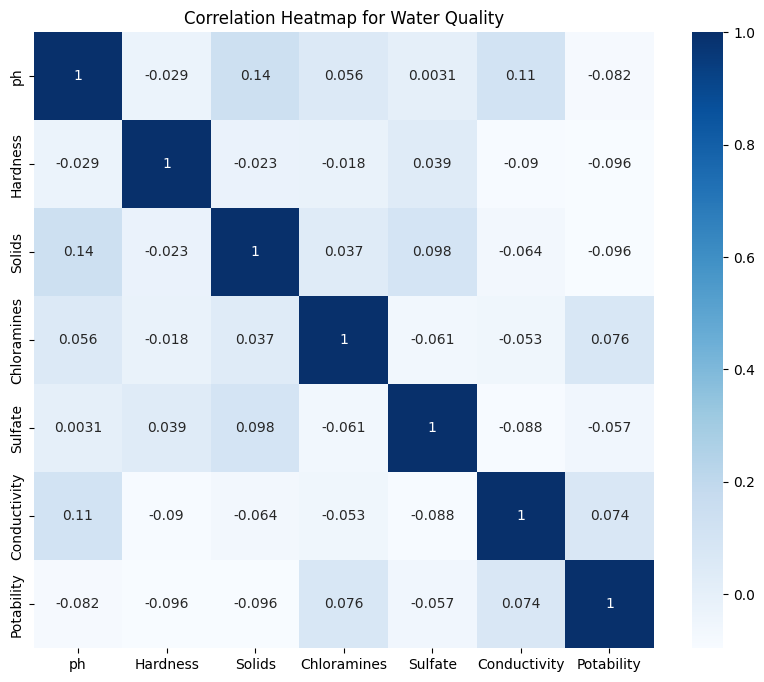

In [ ]:
\plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap for Water Quality')
plt.savefig('classification_heatmap.png')

In [ ]:
# Data Prep
X = df.drop('Potability', axis=1)
y = df['Potability']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Task 1: Neural Network

In [ ]:
nn = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
nn.fit(X_train_scaled, y_train)
nn_pred = nn.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# Task 2: Classical Models

In [ ]:
lr = LogisticRegression()
dt = DecisionTreeClassifier()

lr.fit(X_train_scaled, y_train)
dt.fit(X_train, y_train)

DecisionTreeClassifier()

# Task 4: Hyperparameter Tuning (for DT)


In [ ]:
param_grid = {'max_depth': [3, 5, 10], 'min_samples_split': [2, 5]}
grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)
best_dt_params = grid.best_params_

# Task 5: Feature Selection

In [ ]:
selector = SelectKBest(score_func=chi2, k=4)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]

# Final Comparison Table

In [ ]:
def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

results = {
    'Model': ['Neural Network', 'Logistic Regression', 'Decision Tree (Tuned)'],
    'Accuracy': [accuracy_score(y_test, nn_pred), accuracy_score(y_test, lr.predict(X_test_scaled)), accuracy_score(y_test, grid.predict(X_test))],
    'Precision': [precision_score(y_test, nn_pred), precision_score(y_test, lr.predict(X_test_scaled)), precision_score(y_test, grid.predict(X_test))],
    'Recall': [recall_score(y_test, nn_pred), recall_score(y_test, lr.predict(X_test_scaled)), recall_score(y_test, grid.predict(X_test))],
    'F1': [f1_score(y_test, nn_pred), f1_score(y_test, lr.predict(X_test_scaled)), f1_score(y_test, grid.predict(X_test))]
}

final_df = pd.DataFrame(results)
final_df.to_csv('classification_results.csv', index=False)
print(final_df)
print(selected_features)

                   Model  Accuracy  Precision    Recall        F1
0         Neural Network      0.35        0.5  0.307692  0.380952
1    Logistic Regression      0.35        0.5  0.230769  0.315789
2  Decision Tree (Tuned)      0.50        0.8  0.307692  0.444444
Index(['Hardness', 'Solids', 'Sulfate', 'Conductivity'], dtype='object')
